# 20. Evaluacion 3D de la pseudo-LiDAR refinada

Este notebook cierra el experimento de refinamiento de profundidad. La pregunta ya no es solo si el mapa refinado se parece al LiDAR proyectado en 2D, sino si al reconstruir de nuevo la pseudo-LiDAR se obtiene una nube 3D mas util que la generada directamente con Depth Pro.

La comparacion se hace de forma controlada, se usan los mismos mapas Depth Pro guardados, la misma resolucion, las mismas calibraciones de nuScenes y la misma conversion a pseudo-LiDAR. La unica diferencia es si se usa la profundidad nativa de Depth Pro o la profundidad pasada por la red de refinamiento.

In [ ]:
from pathlib import Path
import json
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import open3d as o3d
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if not (ROOT / 'scripts').exists():
    for parent in Path.cwd().resolve().parents:
        if (parent / 'scripts').exists():
            ROOT = parent
            break
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

PYTHON = sys.executable
SCENE_DIR = ROOT / 'outputs' / 'scene-0061'
FIRST30_DATASET_DIR = SCENE_DIR / 'depth_refinement_dataset_first30'
FIRST5_DATASET_DIR = SCENE_DIR / 'depth_refinement_dataset'
DATASET_DIR = FIRST30_DATASET_DIR if (FIRST30_DATASET_DIR / 'dataset_index.json').exists() else FIRST5_DATASET_DIR

FORCE_REBUILD_REFINED_PSEUDOLIDAR = False
FORCE_REEVALUATE_METRICS = False
RUN_FRONT_AND_TRAJECTORY = True
FORCE_REGENERATE_THESIS_FIGURES = False

REFINER_VARIANT = 'refiner_training_rgb'
CHECKPOINT = DATASET_DIR / REFINER_VARIANT / 'best_depth_refiner.pt'
if DATASET_DIR.name.endswith('first30'):
    REFINED_DIR = SCENE_DIR / ('refined_pseudolidar_rgb_first30' if REFINER_VARIANT.endswith('_rgb') else 'refined_pseudolidar_first30')
else:
    REFINED_DIR = SCENE_DIR / ('refined_pseudolidar_rgb' if REFINER_VARIANT.endswith('_rgb') else 'refined_pseudolidar')
DEPTH_PRO_SUMMARY = REFINED_DIR / 'depth_pro' / 'run_summary.json'
REFINED_SUMMARY = REFINED_DIR / 'refined' / 'run_summary.json'

print('Python kernel:', PYTHON)
print('ROOT:', ROOT)
print('Dataset:', DATASET_DIR)
print('Checkpoint:', CHECKPOINT)
print('Salida:', REFINED_DIR)
print('FORCE_REBUILD_REFINED_PSEUDOLIDAR:', FORCE_REBUILD_REFINED_PSEUDOLIDAR)
print('FORCE_REEVALUATE_METRICS:', FORCE_REEVALUATE_METRICS)
print('RUN_FRONT_AND_TRAJECTORY:', RUN_FRONT_AND_TRAJECTORY)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Python kernel: /home/clara/ml-depth-pro/depthpro_env/bin/python
ROOT: /home/clara/ml-depth-pro/slam_readiness_nuscenes
Dataset: /home/clara/ml-depth-pro/slam_readiness_nuscenes/outputs/scene-0061/depth_refinement_dataset_first30
Checkpoint: /home/clara/ml-depth-pro/slam_readiness_nuscenes/outputs/scene-0061/depth_refinement_dataset_first30/refiner_training_rgb/best_depth_refiner.pt
Salida: /home/clara/ml-depth-pro/slam_readiness_nuscenes/outputs/scene-0061/refined_pseudolidar_rgb_first30
FORCE_REBUILD_REFINED_PSEUDOLIDAR: False
FORCE_REEVALUATE_METRICS: False
RUN_FRONT_AND_TRAJECTORY: True


## 1. Generación y evaluación reproducible

La siguiente celda genera dos versiones de pseudo-LiDAR, una a partir de Depth Pro original y otra a partir de la profundidad refinada. Por defecto, se utiliza la variante con RGB entrenada sobre `depth_refinement_dataset_first30`, y los resultados se guardan en `outputs/scene-0061/refined_pseudolidar_rgb_first30`.

En modo presentación, los flags `FORCE_REBUILD_REFINED_PSEUDOLIDAR` y `FORCE_REEVALUATE_METRICS` se mantienen en `False`, de forma que se reutilizan los resultados ya generados. Si se vuelve a entrenar el modelo de refinamiento, ambos deben cambiarse a `True` para regenerar la pseudo-LiDAR y recalcular las métricas.

Si solo se quieren inspeccionar resultados ya calculados, basta con mantener estos flags en `False` en la primera celda del notebook.

In [2]:
DATAROOT = Path('/home/clara/datasets/nuscenes')
VERSION = 'v1.0-mini'

def run_if_needed(command, expected_path, force=False):
    expected_path = Path(expected_path)
    print('Comando:', ' '.join(map(str, command)))
    if expected_path.exists() and not force:
        print('Ya existe, se reutiliza:', expected_path)
        return
    subprocess.run([str(x) for x in command], check=True, cwd=ROOT)

run_if_needed(
    [
        PYTHON,
        ROOT / 'scripts' / 'generate_refined_pseudolidar_from_dataset.py',
        '--dataset-dir', DATASET_DIR,
        '--checkpoint', CHECKPOINT,
        '--output-dir', REFINED_DIR,
    ],
    REFINED_DIR / 'comparison_index.json',
    force=FORCE_REBUILD_REFINED_PSEUDOLIDAR,
)

run_if_needed(
    [
        PYTHON,
        ROOT / 'scripts' / 'evaluate_refined_pseudolidar_comparison.py',
        '--depth-pro-run-summary', DEPTH_PRO_SUMMARY,
        '--refined-run-summary', REFINED_SUMMARY,
        '--output', REFINED_DIR / 'refined_pseudolidar_comparison.json',
    ],
    REFINED_DIR / 'refined_pseudolidar_comparison.json',
    force=FORCE_REEVALUATE_METRICS,
)

for summary in [DEPTH_PRO_SUMMARY, REFINED_SUMMARY]:
    run_if_needed(
        [PYTHON, ROOT / 'scripts' / 'evaluate_pairwise_registration.py', '--run-summary', summary, '--dataroot', DATAROOT, '--version', VERSION],
        summary.parent / 'pairwise_registration_metrics.json',
        force=FORCE_REEVALUATE_METRICS,
    )
    if RUN_FRONT_AND_TRAJECTORY:
        run_if_needed(
            [PYTHON, ROOT / 'scripts' / 'evaluate_front_best_combination.py', '--run-summary', summary, '--dataroot', DATAROOT, '--version', VERSION],
            summary.parent / 'front_best_combination.json',
            force=FORCE_REEVALUATE_METRICS,
        )
        run_if_needed(
            [PYTHON, ROOT / 'scripts' / 'evaluate_accumulated_trajectory.py', '--run-summary', summary, '--dataroot', DATAROOT, '--version', VERSION],
            summary.parent / 'accumulated_trajectory_comparison.json',
            force=FORCE_REEVALUATE_METRICS,
        )

Comando: /home/clara/ml-depth-pro/depthpro_env/bin/python /home/clara/ml-depth-pro/slam_readiness_nuscenes/scripts/generate_refined_pseudolidar_from_dataset.py --dataset-dir /home/clara/ml-depth-pro/slam_readiness_nuscenes/outputs/scene-0061/depth_refinement_dataset_first30 --checkpoint /home/clara/ml-depth-pro/slam_readiness_nuscenes/outputs/scene-0061/depth_refinement_dataset_first30/refiner_training_rgb/best_depth_refiner.pt --output-dir /home/clara/ml-depth-pro/slam_readiness_nuscenes/outputs/scene-0061/refined_pseudolidar_rgb_first30
Ya existe, se reutiliza: /home/clara/ml-depth-pro/slam_readiness_nuscenes/outputs/scene-0061/refined_pseudolidar_rgb_first30/comparison_index.json
Comando: /home/clara/ml-depth-pro/depthpro_env/bin/python /home/clara/ml-depth-pro/slam_readiness_nuscenes/scripts/evaluate_refined_pseudolidar_comparison.py --depth-pro-run-summary /home/clara/ml-depth-pro/slam_readiness_nuscenes/outputs/scene-0061/refined_pseudolidar_rgb_first30/depth_pro/run_summary.json

### Figuras exportables de la memoria

La siguiente celda genera, solo si faltan o si se activa el flag `FORCE_REGENERATE_THESIS_FIGURES`, las figuras PNG usadas para documentar la evaluación 3D. No recalcula Depth Pro ni vuelve a entrenar la red; solo lee los `.ply` y JSON ya existentes.


In [ ]:
MANIFEST = ROOT / 'manifests' / 'scene-0061_first30.json'
THESIS_FIGURES_DIR = REFINED_DIR / 'figures'
THESIS_FIGURES = {
    'near_mid_far_regions': THESIS_FIGURES_DIR / 'near_mid_far_regions.png',
    'accumulated_trajectory': THESIS_FIGURES_DIR / 'accumulated_trajectory_refined_vs_base.png',
    'overlay': THESIS_FIGURES_DIR / 'pseudolidar_vs_lidar_top_overlay.png',
    'triptych': THESIS_FIGURES_DIR / 'pseudolidar_lidar_top_triptych.png',
    'nn_error': THESIS_FIGURES_DIR / 'refined_vs_base_nn_error.png',
    'registration_good_vs_bad': THESIS_FIGURES_DIR / 'registration_good_vs_bad.png',
}

missing_figures = [path for path in THESIS_FIGURES.values() if not path.exists()]
if FORCE_REGENERATE_THESIS_FIGURES or missing_figures:
    print('Generando figuras exportables para la memoria...')
    subprocess.run(
        [
            PYTHON,
            ROOT / 'scripts' / 'make_thesis_figures.py',
            '--manifest', MANIFEST,
            '--figures-dir', THESIS_FIGURES_DIR,
        ],
        check=True,
        cwd=ROOT,
    )
else:
    print('Figuras exportables ya generadas, se reutilizan.')

for name, path in THESIS_FIGURES.items():
    print(f'{name}: {path}')


## 2. Calidad geometrica frente a LIDAR_TOP

Primero se compara cada pseudo-LiDAR contra el LiDAR real en soporte comun. Aqui una distancia menor es mejor, mientras que un BEV IoU mayor es mejor.

,source,pseudo_points_mean,pseudo_to_gt_mean_nn_m,pseudo_to_gt_median_nn_m,gt_to_pseudo_mean_nn_m,bev_iou
0,depth_pro,14077.233333,0.791447,0.508675,1.314758,0.247440
1,refined,17468.900000,0.643808,0.414356,1.178587,0.254879


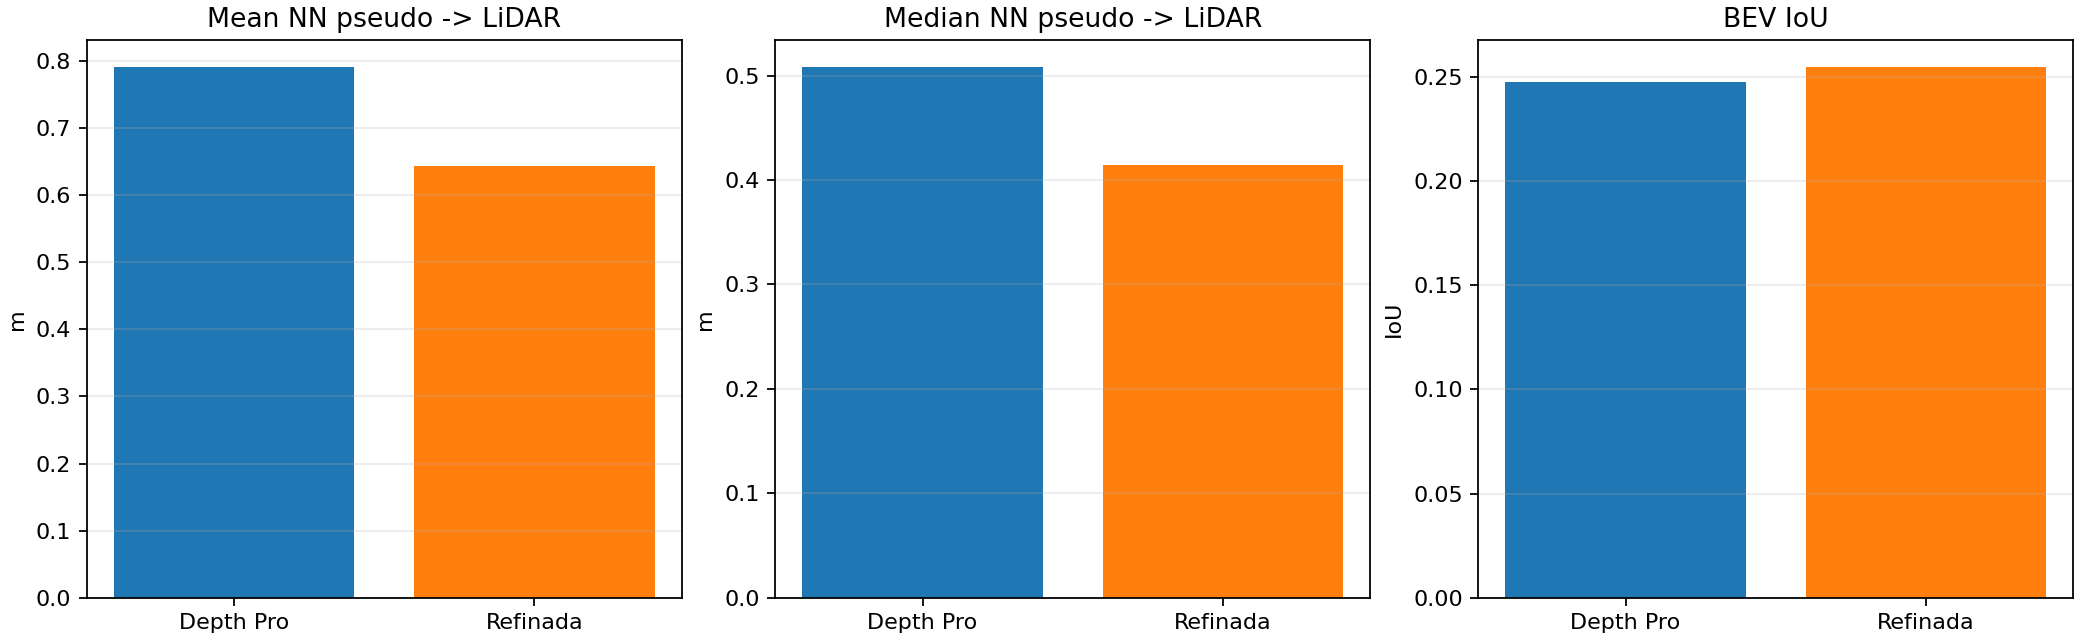

In [3]:
comparison_path = REFINED_DIR / 'refined_pseudolidar_comparison.json'
comparison = json.loads(comparison_path.read_text(encoding='utf-8-sig'))

rows = []
for source, metrics in comparison['aggregate'].items():
    rows.append({
        'source': source,
        'pseudo_points_mean': metrics['pseudo_points_mean'],
        'pseudo_to_gt_mean_nn_m': metrics['pseudo_to_gt_mean_nn_mean'],
        'pseudo_to_gt_median_nn_m': metrics['pseudo_to_gt_median_nn_mean'],
        'gt_to_pseudo_mean_nn_m': metrics['gt_to_pseudo_mean_nn_mean'],
        'bev_iou': metrics['bev_iou_mean'],
    })
geometry_df = pd.DataFrame(rows)
display(geometry_df)

plot_path = comparison_path.with_suffix('.png')
if plot_path.exists():
    display(Image(filename=str(plot_path)))

### Visualizaciones de calidad geometrica

Estas figuras corresponden a la comparacion frente a `LIDAR_TOP` en el mismo soporte comun usado para las metricas, rango 2-35 m y altura entre -2 y 2.5 m. El triptico separa la pseudo-LiDAR, el LiDAR real y la superposicion para facilitar la comparacion visual. Despues se mantiene la superposicion en BEV/perspectiva y el mapa de error nearest-neighbor.

![Pseudo-LiDAR, LIDAR_TOP y superposicion](../outputs/scene-0061/refined_pseudolidar_rgb_first30/figures/pseudolidar_lidar_top_triptych.png)

![Overlay pseudo-LiDAR base frente a LIDAR_TOP](../outputs/scene-0061/refined_pseudolidar_rgb_first30/figures/pseudolidar_vs_lidar_top_overlay.png)

![Error nearest-neighbor base frente a refinada](../outputs/scene-0061/refined_pseudolidar_rgb_first30/figures/refined_vs_base_nn_error.png)


## 3. Registro temporal básico

Después se repite el registro ICP frame a frame. Esta métrica responde a la pregunta práctica de si la nube refinada mejora la estimación del movimiento entre frames.


,source,translation_error_mean_m,rotation_error_mean_deg,fitness_mean
0,depth_pro,1.038582,1.204683,0.820638
1,refined,0.586114,0.900401,0.840925
2,lidar_gt_baseline,0.045428,0.182475,0.896527


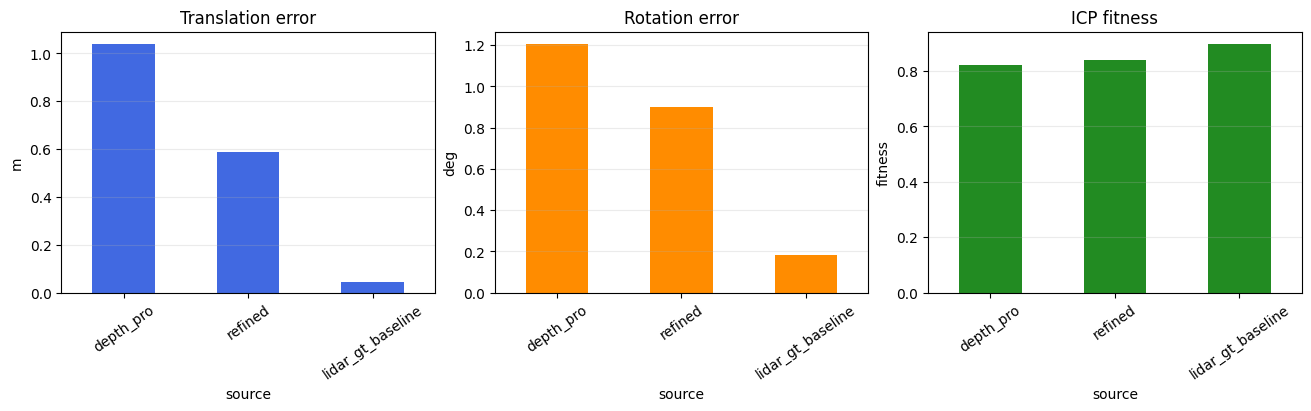

In [4]:
def load_json(path):
    return json.loads(Path(path).read_text(encoding='utf-8-sig'))

depth_pro_reg = load_json(DEPTH_PRO_SUMMARY.parent / 'pairwise_registration_metrics.json')
refined_reg = load_json(REFINED_SUMMARY.parent / 'pairwise_registration_metrics.json')

registration_df = pd.DataFrame([
    {
        'source': 'depth_pro',
        'translation_error_mean_m': depth_pro_reg['aggregate']['pseudo_translation_error_mean_m'],
        'rotation_error_mean_deg': depth_pro_reg['aggregate']['pseudo_rotation_error_mean_deg'],
        'fitness_mean': depth_pro_reg['aggregate']['pseudo_fitness_mean'],
    },
    {
        'source': 'refined',
        'translation_error_mean_m': refined_reg['aggregate']['pseudo_translation_error_mean_m'],
        'rotation_error_mean_deg': refined_reg['aggregate']['pseudo_rotation_error_mean_deg'],
        'fitness_mean': refined_reg['aggregate']['pseudo_fitness_mean'],
    },
    {
        'source': 'lidar_gt_baseline',
        'translation_error_mean_m': refined_reg['aggregate']['gt_translation_error_mean_m'],
        'rotation_error_mean_deg': refined_reg['aggregate']['gt_rotation_error_mean_deg'],
        'fitness_mean': refined_reg['aggregate']['gt_fitness_mean'],
    },
])
display(registration_df)

fig, axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)
registration_df.plot.bar(x='source', y='translation_error_mean_m', ax=axes[0], legend=False, color='royalblue')
registration_df.plot.bar(x='source', y='rotation_error_mean_deg', ax=axes[1], legend=False, color='darkorange')
registration_df.plot.bar(x='source', y='fitness_mean', ax=axes[2], legend=False, color='forestgreen')
axes[0].set_title('Translation error')
axes[1].set_title('Rotation error')
axes[2].set_title('ICP fitness')
axes[0].set_ylabel('m')
axes[1].set_ylabel('deg')
axes[2].set_ylabel('fitness')
for ax in axes:
    ax.tick_params(axis='x', rotation=35)
    ax.grid(axis='y', alpha=0.25)
plt.show()

## 4. Estrategias frontales y trayectoria acumulada

Aqui se comprueba si el refinamiento tambien mejora las estrategias que antes funcionaban mejor en la zona frontal. Es importante mirarlo separado porque una nube puede mejorar el ICP directo pero no necesariamente la inicializacion global + ICP.

In [5]:
def front_rows(source_name, path):
    data = load_json(path)
    metrics_by_strategy = data.get('aggregate', data)
    rows = []
    for strategy, metrics in metrics_by_strategy.items():
        row = {'source': source_name, 'strategy': strategy}
        row.update(metrics)
        rows.append(row)
    return rows

front_df = pd.DataFrame(
    front_rows('depth_pro', DEPTH_PRO_SUMMARY.parent / 'front_best_combination.json')
    + front_rows('refined', REFINED_SUMMARY.parent / 'front_best_combination.json')
)
display(front_df)

def trajectory_rows(source_name, path):
    data = load_json(path)
    rows = []
    for strategy, item in data['trajectories'].items():
        row = {'source': source_name, 'strategy': strategy}
        row.update(item['aggregate'])
        rows.append(row)
    return rows

trajectory_df = pd.DataFrame(
    trajectory_rows('depth_pro', DEPTH_PRO_SUMMARY.parent / 'accumulated_trajectory_comparison.json')
    + trajectory_rows('refined', REFINED_SUMMARY.parent / 'accumulated_trajectory_comparison.json')
)
display(trajectory_df)

,source,strategy,translation_error_mean_m,rotation_error_mean_deg,fitness_mean,rmse_mean,num_valid_pairs
0,depth_pro,front_baseline_cfg05,3.545551,15.602878,0.879619,0.621537,29
1,depth_pro,front_narrow_cfg05,2.938642,8.162472,0.892833,0.585356,29
2,refined,front_baseline_cfg05,3.622205,14.241776,0.890957,0.598578,29
3,refined,front_narrow_cfg05,1.684783,8.125714,0.905807,0.549585,29


,source,strategy,mean_translation_error_m,mean_rotation_error_deg,final_translation_error_m,final_rotation_error_deg,num_frames
0,depth_pro,front_icp_only,24.681957,19.929393,37.355452,31.329176,30
1,depth_pro,front_baseline_cfg05,33.011301,96.632271,58.193924,176.908135,30
2,depth_pro,front_narrow_cfg05,18.216851,85.142150,34.474191,174.901033,30
3,refined,front_icp_only,30.138930,10.009181,40.480744,15.566454,30
4,refined,front_baseline_cfg05,49.747195,18.113202,76.174858,9.827835,30
5,refined,front_narrow_cfg05,25.082445,114.898492,47.792836,170.090129,30


### Figuras exportables de registro temporal

La trayectoria acumulada se muestra sobre la configuracion `first30`, con treinta frames encadenados, usando `front_baseline_cfg05`. Por eso no debe compararse directamente con la tabla de trayectoria `first5`: al encadenar mas frames, la deriva acumulada crece de forma natural. En esta ejecucion, el error final de traslacion es 58.19 m para Depth Pro base y 76.17 m para Depth Pro+RGB refinada; el error final de rotacion es 176.91 grados y 9.83 grados, respectivamente. La figura de registro compara un caso bueno y uno malo seleccionados desde las metricas por par, aplicando la transformacion estimada guardada en el experimento.

![Trayectoria acumulada base frente a refinada](../outputs/scene-0061/refined_pseudolidar_rgb_first30/figures/accumulated_trajectory_refined_vs_base.png)

![Ejemplo de registro bueno frente a malo](../outputs/scene-0061/refined_pseudolidar_rgb_first30/figures/registration_good_vs_bad.png)


### Cierre: trayectoria acumulada refinada en first30

Esta subseccion responde explicitamente a la ultima pregunta del refinamiento: si la mejora en profundidad, nube 3D y registro par a par se traduce tambien en una menor deriva acumulada. Se usa `first30`, por lo que estos valores no deben compararse directamente con la tabla `first5` del baseline.


In [ ]:
ACCUM_STRATEGIES = ['front_icp_only', 'front_baseline_cfg05', 'front_narrow_cfg05']
ACCUM_FIG_DIR = REFINED_DIR / 'figures'
ACCUM_DEPTH_PATH = DEPTH_PRO_SUMMARY.parent / 'accumulated_trajectory_comparison.json'
ACCUM_REFINED_PATH = REFINED_SUMMARY.parent / 'accumulated_trajectory_comparison.json'

accum_depth = load_json(ACCUM_DEPTH_PATH)
accum_refined = load_json(ACCUM_REFINED_PATH)

accum_rows = []
for strategy in ACCUM_STRATEGIES:
    base_metrics = accum_depth['trajectories'][strategy]['aggregate']
    refined_metrics = accum_refined['trajectories'][strategy]['aggregate']
    accum_rows.append({
        'strategy': strategy,
        'num_frames': base_metrics['num_frames'],
        'base_final_translation_m': base_metrics['final_translation_error_m'],
        'refined_final_translation_m': refined_metrics['final_translation_error_m'],
        'translation_delta_m': refined_metrics['final_translation_error_m'] - base_metrics['final_translation_error_m'],
        'translation_change_pct': (base_metrics['final_translation_error_m'] - refined_metrics['final_translation_error_m']) / base_metrics['final_translation_error_m'] * 100.0,
        'base_final_rotation_deg': base_metrics['final_rotation_error_deg'],
        'refined_final_rotation_deg': refined_metrics['final_rotation_error_deg'],
        'rotation_delta_deg': refined_metrics['final_rotation_error_deg'] - base_metrics['final_rotation_error_deg'],
        'rotation_change_pct': (base_metrics['final_rotation_error_deg'] - refined_metrics['final_rotation_error_deg']) / base_metrics['final_rotation_error_deg'] * 100.0 if base_metrics['final_rotation_error_deg'] else np.nan,
    })

accumulated_refined_df = pd.DataFrame(accum_rows)
display(accumulated_refined_df.round(3))


In [ ]:
ACCUM_FIG_DIR.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2), constrained_layout=True)
x = np.arange(len(ACCUM_STRATEGIES))
width = 0.36

axes[0].bar(x - width / 2, accumulated_refined_df['base_final_translation_m'], width, label='Depth Pro base', color='tab:blue')
axes[0].bar(x + width / 2, accumulated_refined_df['refined_final_translation_m'], width, label='Depth Pro+RGB refinada', color='tab:orange')
axes[0].set_title('Error final de traslacion acumulada')
axes[0].set_ylabel('m')
axes[0].set_xticks(x)
axes[0].set_xticklabels(ACCUM_STRATEGIES, rotation=20, ha='right')
axes[0].grid(axis='y', alpha=0.25)
axes[0].legend(frameon=True)

axes[1].bar(x - width / 2, accumulated_refined_df['base_final_rotation_deg'], width, label='Depth Pro base', color='tab:blue')
axes[1].bar(x + width / 2, accumulated_refined_df['refined_final_rotation_deg'], width, label='Depth Pro+RGB refinada', color='tab:orange')
axes[1].set_title('Error final de rotacion acumulada')
axes[1].set_ylabel('grados')
axes[1].set_xticks(x)
axes[1].set_xticklabels(ACCUM_STRATEGIES, rotation=20, ha='right')
axes[1].grid(axis='y', alpha=0.25)
axes[1].legend(frameon=True)

out_path = ACCUM_FIG_DIR / 'accumulated_trajectory_final_errors.png'
fig.savefig(out_path, dpi=300, bbox_inches='tight', facecolor='white')
print(out_path)
plt.show()


![Errores finales de trayectoria acumulada](../outputs/scene-0061/refined_pseudolidar_rgb_first30/figures/accumulated_trajectory_final_errors.png)


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.6), constrained_layout=True)
for ax, strategy in zip(axes, ACCUM_STRATEGIES):
    base_item = accum_depth['trajectories'][strategy]
    refined_item = accum_refined['trajectories'][strategy]
    gt_xy = np.asarray(base_item.get('gt_trajectory_xy') or accum_depth['gt_trajectory_xy'], dtype=np.float32)
    base_xy = np.asarray(base_item['trajectory_xy'], dtype=np.float32)
    refined_xy = np.asarray(refined_item['trajectory_xy'], dtype=np.float32)

    ax.plot(gt_xy[:, 0], gt_xy[:, 1], '-o', color='black', linewidth=2.0, markersize=2.4, label='referencia nuScenes')
    ax.plot(base_xy[:, 0], base_xy[:, 1], '-o', color='tab:blue', linewidth=1.6, markersize=2.2, label='Depth Pro base')
    ax.plot(refined_xy[:, 0], refined_xy[:, 1], '-o', color='tab:orange', linewidth=1.6, markersize=2.2, label='Depth Pro+RGB refinada')
    ax.scatter(gt_xy[0, 0], gt_xy[0, 1], marker='s', s=40, color='black', label='inicio')
    ax.set_title(strategy)
    ax.set_xlabel('x ego (m)')
    ax.set_ylabel('y ego (m)')
    ax.set_aspect('equal', adjustable='box')
    ax.grid(alpha=0.2)
axes[0].legend(loc='best', frameon=True)

out_path = ACCUM_FIG_DIR / 'accumulated_trajectory_all_strategies.png'
fig.savefig(out_path, dpi=300, bbox_inches='tight', facecolor='white')
print(out_path)
plt.show()


![Trayectorias acumuladas por estrategia](../outputs/scene-0061/refined_pseudolidar_rgb_first30/figures/accumulated_trajectory_all_strategies.png)


In [ ]:
front = accumulated_refined_df[accumulated_refined_df['strategy'] == 'front_baseline_cfg05'].iloc[0]
icp = accumulated_refined_df[accumulated_refined_df['strategy'] == 'front_icp_only'].iloc[0]

summary = (
    f"**Conclusion acumulada.** En `first30`, el refinamiento `Depth Pro + RGB` no reduce de forma robusta "
    f"la deriva traslacional acumulada. En `front_baseline_cfg05`, el error final de traslacion pasa de "
    f"{front.base_final_translation_m:.2f} m a {front.refined_final_translation_m:.2f} m, por lo que empeora en traslacion. "
    f"Sin embargo, el error final de rotacion baja de {front.base_final_rotation_deg:.2f} grados a "
    f"{front.refined_final_rotation_deg:.2f} grados. En `front_icp_only` aparece una lectura similar: "
    f"la rotacion final baja de {icp.base_final_rotation_deg:.2f} grados a {icp.refined_final_rotation_deg:.2f} grados, "
    f"pero la traslacion pasa de {icp.base_final_translation_m:.2f} m a {icp.refined_final_translation_m:.2f} m."
    f"Por tanto, la mejora local en profundidad, nube 3D y registro par a par no garantiza por si sola una odometria "
    f"acumulada estable. La pseudo-LiDAR refinada puede actuar como senal geometrica adicional, pero no sustituye "
    f"a un LiDAR real en SLAM robusto."
)
display(Markdown(summary))


## 5. Resumen destacable first30

Esta celda recoge solo los resultados principales de la ejecución ampliada con 30 samples de `scene-0061` y la U-Net residual con entrada `Depth Pro + RGB`.


In [6]:
from IPython.display import Markdown, display

DEPTH_EVAL_PATH = DATASET_DIR / REFINER_VARIANT / 'refined_depth_eval.json'
GEOM_PATH = REFINED_DIR / 'refined_pseudolidar_comparison.json'
ICP_DEPTH_PATH = DEPTH_PRO_SUMMARY.parent / 'pairwise_registration_metrics.json'
ICP_REFINED_PATH = REFINED_SUMMARY.parent / 'pairwise_registration_metrics.json'
FRONT_DEPTH_PATH = DEPTH_PRO_SUMMARY.parent / 'front_best_combination.json'
FRONT_REFINED_PATH = REFINED_SUMMARY.parent / 'front_best_combination.json'
TRAJ_DEPTH_PATH = DEPTH_PRO_SUMMARY.parent / 'accumulated_trajectory_comparison.json'
TRAJ_REFINED_PATH = REFINED_SUMMARY.parent / 'accumulated_trajectory_comparison.json'


def pct_improvement(before, after, lower_is_better=True):
    if before == 0 or pd.isna(before) or pd.isna(after):
        return np.nan
    value = (before - after) / before * 100.0 if lower_is_better else (after - before) / before * 100.0
    return value


def compact_improvement(before, after, lower_is_better=True):
    value = pct_improvement(before, after, lower_is_better=lower_is_better)
    if pd.isna(value):
        return ''
    sign = '+' if value >= 0 else ''
    return f'{sign}{value:.1f}%'


def add_row(rows, bloque, metrica, depth_pro, refined, unit='', lower_is_better=True):
    rows.append({
        'bloque': bloque,
        'metrica': metrica,
        'Depth Pro': depth_pro,
        'Depth Pro + RGB': refined,
        'mejora': compact_improvement(depth_pro, refined, lower_is_better=lower_is_better),
        'unidad': unit,
    })

if not all(path.exists() for path in [DEPTH_EVAL_PATH, GEOM_PATH, ICP_DEPTH_PATH, ICP_REFINED_PATH]):
    print('Faltan resultados para construir el resumen destacable.')
else:
    depth_data = load_json(DEPTH_EVAL_PATH)
    depth_metrics = depth_data.get('aggregate', depth_data)
    geom = load_json(GEOM_PATH)['aggregate']
    icp_depth = load_json(ICP_DEPTH_PATH)['aggregate']
    icp_refined = load_json(ICP_REFINED_PATH)['aggregate']

    highlight_rows = []
    add_row(highlight_rows, 'Profundidad sparse', 'MAE', depth_metrics['depth_pro']['mae_m'], depth_metrics['refined']['mae_m'], 'm')
    add_row(highlight_rows, 'Profundidad sparse', 'RMSE', depth_metrics['depth_pro']['rmse_m'], depth_metrics['refined']['rmse_m'], 'm')
    add_row(highlight_rows, 'Pseudo-LiDAR vs LiDAR', 'mean NN', geom['depth_pro']['pseudo_to_gt_mean_nn_mean'], geom['refined']['pseudo_to_gt_mean_nn_mean'], 'm')
    add_row(highlight_rows, 'Pseudo-LiDAR vs LiDAR', 'BEV IoU', geom['depth_pro']['bev_iou_mean'], geom['refined']['bev_iou_mean'], '', lower_is_better=False)
    add_row(highlight_rows, 'ICP basico', 'error traslacion', icp_depth['pseudo_translation_error_mean_m'], icp_refined['pseudo_translation_error_mean_m'], 'm')
    add_row(highlight_rows, 'ICP basico', 'error rotacion', icp_depth['pseudo_rotation_error_mean_deg'], icp_refined['pseudo_rotation_error_mean_deg'], 'deg')
    add_row(highlight_rows, 'ICP basico', 'fitness', icp_depth['pseudo_fitness_mean'], icp_refined['pseudo_fitness_mean'], '', lower_is_better=False)

    if FRONT_DEPTH_PATH.exists() and FRONT_REFINED_PATH.exists():
        front_depth = load_json(FRONT_DEPTH_PATH)['aggregate']['front_narrow_cfg05']
        front_refined = load_json(FRONT_REFINED_PATH)['aggregate']['front_narrow_cfg05']
        add_row(highlight_rows, 'Front narrow cfg05', 'error traslacion', front_depth['translation_error_mean_m'], front_refined['translation_error_mean_m'], 'm')
        add_row(highlight_rows, 'Front narrow cfg05', 'error rotacion', front_depth['rotation_error_mean_deg'], front_refined['rotation_error_mean_deg'], 'deg')

    highlight_df = pd.DataFrame(highlight_rows)
    numeric_cols = ['Depth Pro', 'Depth Pro + RGB']
    display(highlight_df.style.format({col: '{:.3f}' for col in numeric_cols}))

    bullets = [
        f"- La profundidad sparse mejora en MAE de {depth_metrics['depth_pro']['mae_m']:.2f} m a {depth_metrics['refined']['mae_m']:.2f} m.",
        f"- La distancia media pseudo-LiDAR a LIDAR_TOP baja de {geom['depth_pro']['pseudo_to_gt_mean_nn_mean']:.3f} m a {geom['refined']['pseudo_to_gt_mean_nn_mean']:.3f} m.",
        f"- El ICP basico reduce el error de traslacion de {icp_depth['pseudo_translation_error_mean_m']:.2f} m a {icp_refined['pseudo_translation_error_mean_m']:.2f} m.",
    ]
    if TRAJ_DEPTH_PATH.exists() and TRAJ_REFINED_PATH.exists():
        traj_depth = load_json(TRAJ_DEPTH_PATH)['trajectories']['front_icp_only']['aggregate']
        traj_refined = load_json(TRAJ_REFINED_PATH)['trajectories']['front_icp_only']['aggregate']
        bullets.append(
            f"- En trayectoria acumulada frontal, la rotacion mejora de {traj_depth['final_rotation_error_deg']:.2f} deg a {traj_refined['final_rotation_error_deg']:.2f} deg, pero la traslacion final no mejora ({traj_depth['final_translation_error_m']:.2f} m frente a {traj_refined['final_translation_error_m']:.2f} m)."
        )
    bullets.append('- Lectura: el refinamiento mejora geometria y registro local, pero no debe presentarse como SLAM robusto.')
    display(Markdown('\n'.join(bullets)))


,bloque,metrica,Depth Pro,Depth Pro + RGB,mejora,unidad
0,Profundidad sparse,MAE,4.113,2.838,+31.0%,m
1,Profundidad sparse,RMSE,29.378,5.908,+79.9%,m
2,Pseudo-LiDAR vs LiDAR,mean NN,0.791,0.644,+18.7%,m
3,Pseudo-LiDAR vs LiDAR,BEV IoU,0.247,0.255,+3.0%,
4,ICP basico,error traslacion,1.039,0.586,+43.6%,m
5,ICP basico,error rotacion,1.205,0.900,+25.3%,deg
6,ICP basico,fitness,0.821,0.841,+2.5%,
7,Front narrow cfg05,error traslacion,2.939,1.685,+42.7%,m
8,Front narrow cfg05,error rotacion,8.162,8.126,+0.5%,deg


- La profundidad sparse mejora en MAE de 4.11 m a 2.84 m.
- La distancia media pseudo-LiDAR a LIDAR_TOP baja de 0.791 m a 0.644 m.
- El ICP basico reduce el error de traslacion de 1.04 m a 0.59 m.
- En trayectoria acumulada frontal, la rotacion mejora de 31.33 deg a 15.57 deg, pero la traslacion final no mejora (37.36 m frente a 40.48 m).
- Lectura: el refinamiento mejora geometria y registro local, pero no debe presentarse como SLAM robusto.

## 6. Visualizacion BEV de nubes de puntos

Esta visualizacion no sustituye a una inspeccion 3D interactiva, pero permite ver en el notebook si la distribucion espacial cambia al usar profundidad refinada.

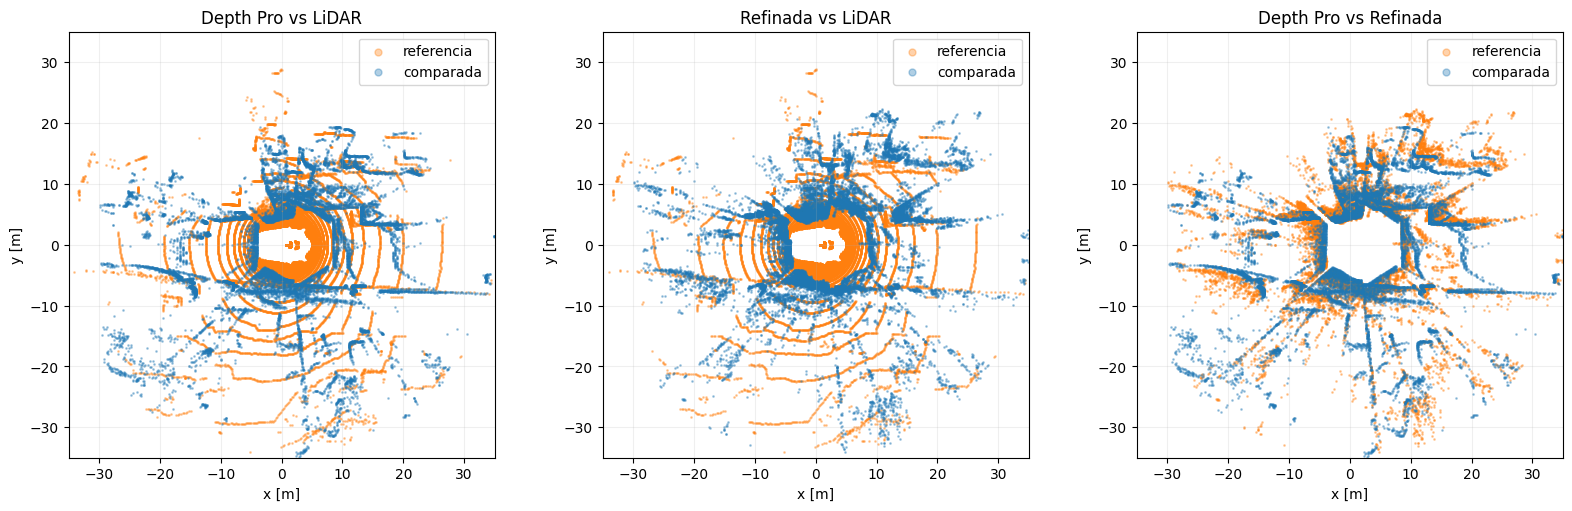

In [7]:
def load_points(path):
    pcd = o3d.io.read_point_cloud(str(path))
    return np.asarray(pcd.points, dtype=np.float32)

def support(points, r_min=2.0, r_max=35.0, z_min=-2.0, z_max=2.5):
    r = np.linalg.norm(points[:, :3], axis=1)
    mask = (r >= r_min) & (r <= r_max) & (points[:, 2] >= z_min) & (points[:, 2] <= z_max)
    return points[mask]

def sample_by_index(summary, sample_index=0):
    for item in summary['samples']:
        if int(item['index']) == sample_index:
            return item
    return summary['samples'][0]

depth_pro_summary = load_json(DEPTH_PRO_SUMMARY)
refined_summary = load_json(REFINED_SUMMARY)
sample_index = 0
depth_item = sample_by_index(depth_pro_summary, sample_index)
refined_item = sample_by_index(refined_summary, sample_index)

lidar = support(load_points(depth_item['lidar_path']))
native = support(load_points(depth_item['pseudo_path']))
refined = support(load_points(refined_item['pseudo_path']))

fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
plots = [
    ('Depth Pro vs LiDAR', native, lidar),
    ('Refinada vs LiDAR', refined, lidar),
    ('Depth Pro vs Refinada', native, refined),
]
for ax, (title, a, b) in zip(axes, plots):
    ax.scatter(b[:, 0], b[:, 1], s=1, alpha=0.35, label='referencia', c='tab:orange')
    ax.scatter(a[:, 0], a[:, 1], s=1, alpha=0.35, label='comparada', c='tab:blue')
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(-35, 35)
    ax.set_ylim(-35, 35)
    ax.set_title(title)
    ax.set_xlabel('x [m]')
    ax.set_ylabel('y [m]')
    ax.grid(alpha=0.2)
    ax.legend(markerscale=5)
plt.show()

### Figura exportable de regiones por distancia

Esta figura resume la distribución BEV de la pseudo-LiDAR base separando rangos cercano, medio y lejano. Sirve para ilustrar por qué el error de profundidad y la calidad del registro no afectan igual a todas las zonas del anillo.

![Regiones near, mid y far de la pseudo-LiDAR base](../outputs/scene-0061/refined_pseudolidar_rgb_first30/figures/near_mid_far_regions.png)


## 7. Lectura intermedia

La variante RGB mejora la comparacion geometrica directa frente a `LIDAR_TOP`, reduce la distancia nearest-neighbor media y sube la ocupacion BEV respecto a Depth Pro nativo generado desde los mismos mapas guardados. Tambien mejora el ICP basico entre frames, bajando el error medio de traslacion y rotacion.

La lectura no es todavia una victoria completa las estrategias frontales y la trayectoria acumulada empeoran con la nube refinada RGB. Probablemente esas estrategias, que estaban ajustadas para la densidad/distribucion de Depth Pro nativo, necesitan una nueva seleccion de puntos o nuevos parametros de registro para esta nube mas densa. La variante solo-depth queda como ablation mejoraba algo la profundidad sparse del notebook 19, pero empeoraba la nube 3D.